<a href="https://colab.research.google.com/github/overgroove/samsung_lecture/blob/main/02_feature_eng_missing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Missing Value**
- 데이터 수집 과정에서 누락 혹은 있어야 할 자리에 없는 데이터를 NaN, None으로 표현  
- 일반적으로는 missing value(null, 결측데이터)라 칭함  
- 일반적인 ML/DL모델의 경우 결측데이터가 하나라도 있으면 학습 불가
- 데이터 전처리 과정에서 가장 먼저 수행해야 할 작업 중 하나  
- 데이터 도메인 / 결측데이터 비율에 따라 결측데이터가 포함 되어 있는 행, 컬럼을 삭제처리  
- 다만 최대한 결측 데이터를 채워넣는(보간) 작업을 통해 결측 데이터를 처리하려는 시도를 합니다.

## **1. data loading**

In [1]:
# 필요모듈 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
from xgboost import XGBRegressor

pd.options.display.max_columns = 200
pd.options.display.max_rows = 200

In [2]:
# ames데이터 로딩
fetch_opemnml_ames = fetch_openml(name='house_prices', as_frame=True)
df = fetch_opemnml_ames['frame']
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# 로딩데이터 확인


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## **2. Baseline model**
- baseline model이란?
  - prediction/classification 모델 중 가장 기본적인 모델을 사용하며 전처리 혹은 모델링 이후의 퍼포먼스 비교를 목적으로 사용    

- feature engineering의 효과를 비교하기 위한 전처리 전 기본 모델로 결측데이터가 있어 XGBRegressor모델을 사용합니다.

In [3]:
# 타겟데이터 분리
y = df['SalePrice']
X = df.drop('SalePrice', axis=1)

# 학습데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 유니크 딕셔너리 카테고리컬 변환
unique_dict = {}
for c in X_train.columns:
    if X_train[c].dtype == 'object':
        unique_dict[c] = {k: i for i, k in enumerate(X_train[c].unique(), 0)}

# 문자열 변환
for c in unique_dict:
    X_train[c] = X_train[c].map(unique_dict[c])
    X_test[c] = X_test[c].map(unique_dict[c])

# 모델링 이후 평가지표 확인
model = XGBRegressor(random_state=42)
pred = model.fit(X_train, y_train).predict(X_test)
print(f'RMSE: {root_mean_squared_error(y_test, pred)}')
print(f'R2: {r2_score(y_test, pred)}')

RMSE: 27501.912109375
R2: 0.9013920426368713


## **Check missing value**
- 데이터셋 내 결측데이터를 여러가지 방법을 통해 확인합니다.
- info(), missingno 시각화, isna()

In [4]:
# info() 메소드로 데이터프레임 간략 정보 확인
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

<Axes: >

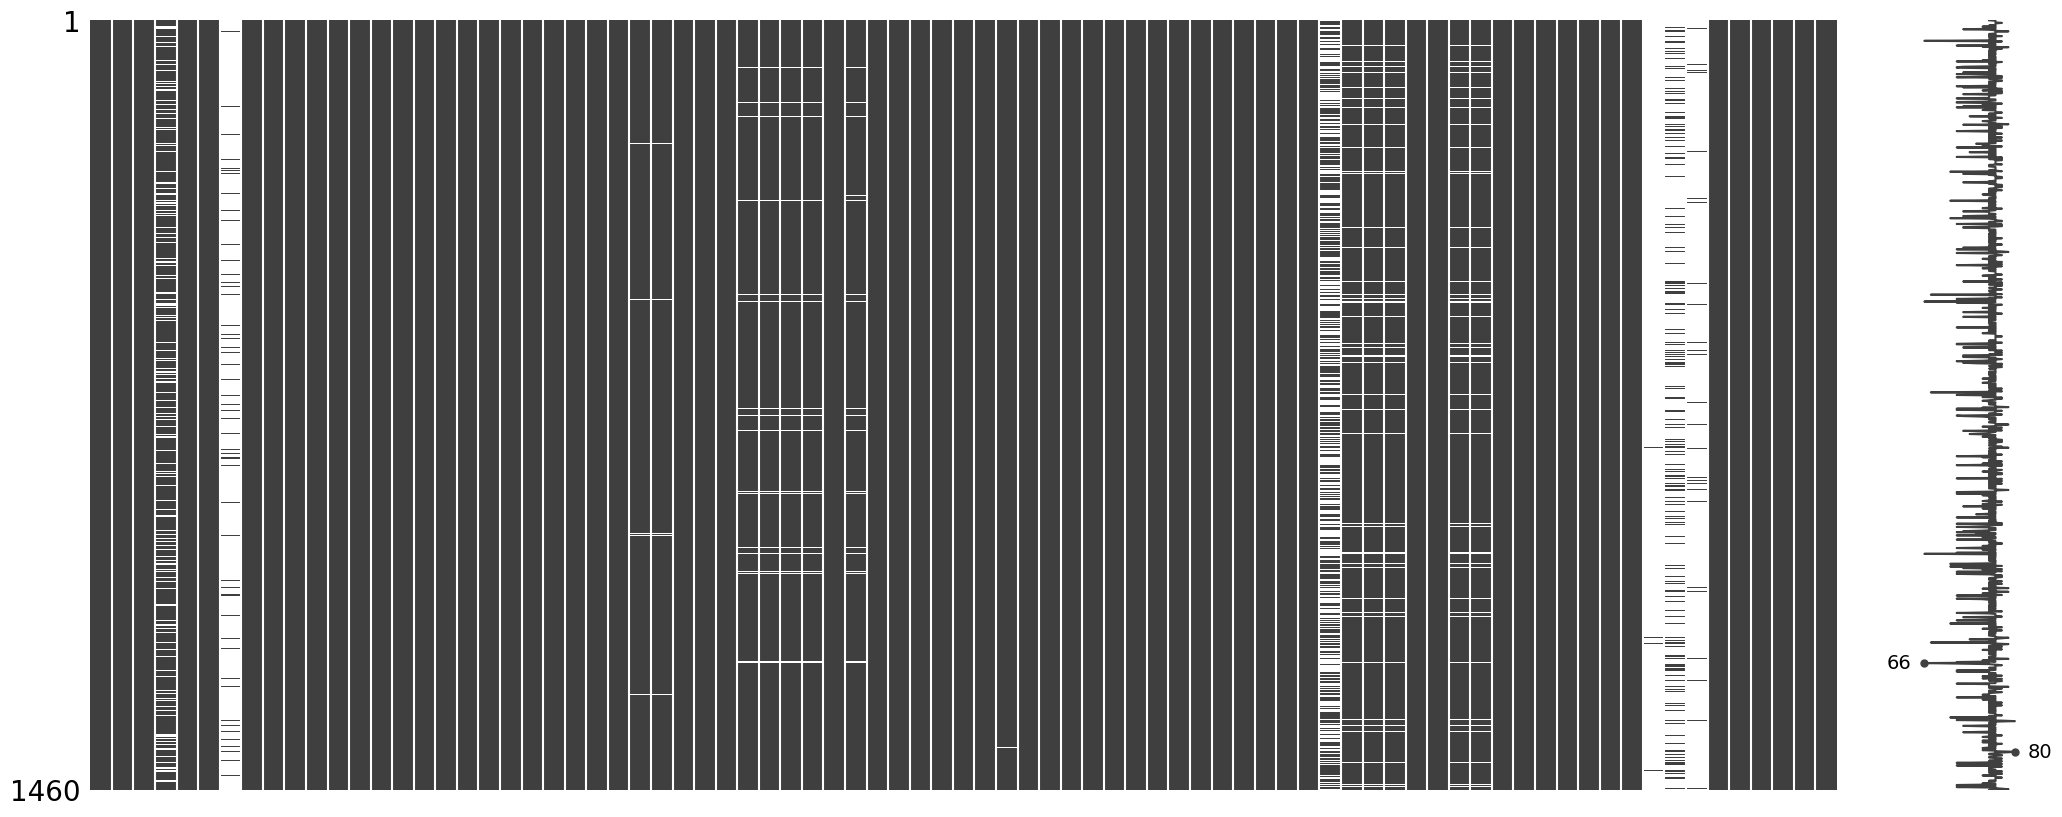

In [5]:
# missingno 패키지 활용 전체 데이터프레임 샘플 결측치 시각화
import missingno as msno
msno.matrix(df)

<Axes: >

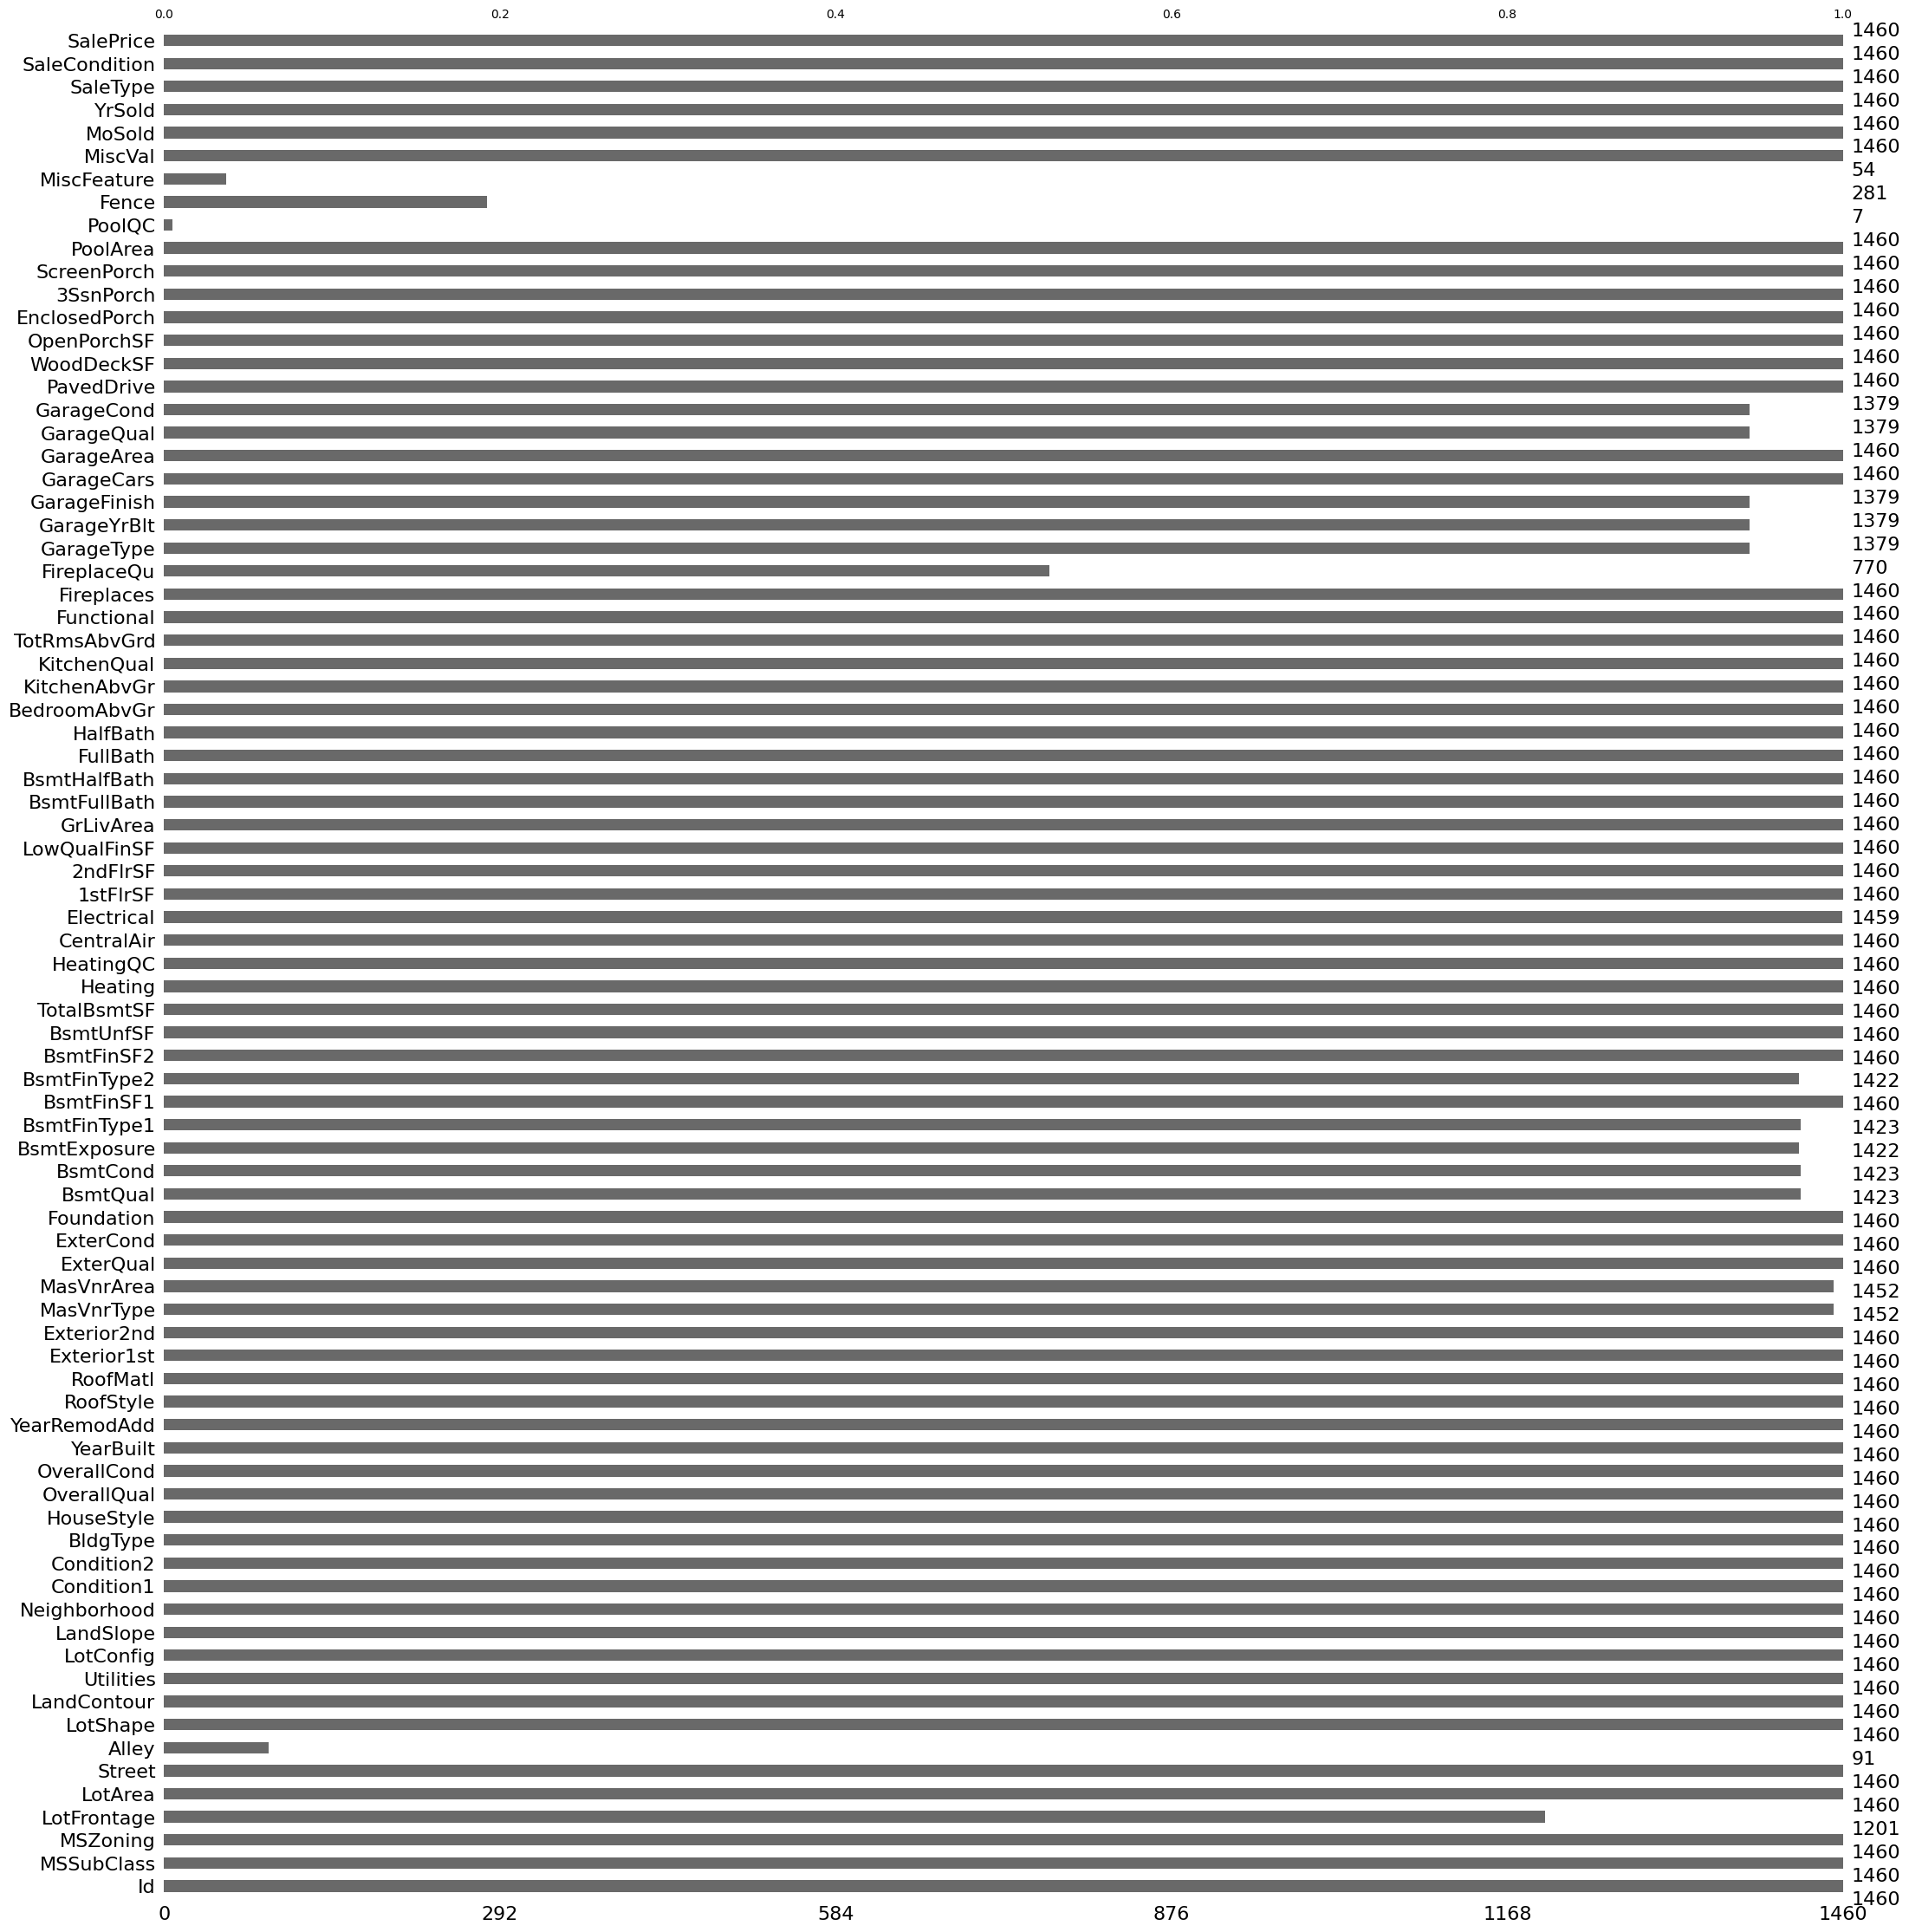

In [6]:
# missingno 패키지 활용 각 변수별 결측 비율 시각화
msno.bar(df)

In [8]:
# PoolQC
df['PoolQC'].unique() # 고윳값 - 중복데이터 제거

array([nan, 'Ex', 'Fa', 'Gd'], dtype=object)

In [11]:
# 컬럼별 결측 데이터 갯수 확인
df.isna().sum()
df.isna().mean()

,0
Id,0.000000
MSSubClass,0.000000
MSZoning,0.000000
LotFrontage,0.177397
LotArea,0.000000
Street,0.000000
Alley,0.937671
LotShape,0.000000
LandContour,0.000000
Utilities,0.000000


In [15]:
# LotFrontage 컬럼데이터 및 결측 데이터 갯수 확인
# 부지에 연결된 도로의 직선 거리 (단위: 피트)
df['LotFrontage'].isna().sum() # 갯수
df['LotFrontage'].isna().mean() # 비율

np.float64(0.1773972602739726)

In [ ]:
# LotFrontage 컬럼 결측 비율 계산


np.float64(17.73972602739726)

In [19]:
# LotFrontage 컬럼의 결측 데이터 샘플 확인
# 팬시인덱싱
df.loc[df['LotFrontage'].isna(), :]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
12,13,20,RL,NaN,12968,Pave,NaN,IR2,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,1Fam,1Story,5,6,1962,1962,Hip,CompShg,HdBoard,Plywood,None,0.0,TA,TA,CBlock,TA,TA,No,ALQ,737,Unf,0,175,912,GasA,TA,Y,SBrkr,912,0,0,912,1,0,1,0,2,1,TA,4,Typ,0,NaN,Detchd,1962.0,Unf,1,352,TA,TA,Y,140,0,0,0,176,0,NaN,NaN,NaN,0,9,2008,WD,Normal,144000
14,15,20,RL,NaN,10920,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,MetalSd,MetalSd,BrkFace,212.0,TA,TA,CBlock,TA,TA,No,BLQ,733,Unf,0,520,1253,GasA,TA,Y,SBrkr,1253,0,0,1253,1,0,1,1,2,1,TA,5,Typ,1,Fa,Attchd,1960.0,RFn,1,352,TA,TA,Y,0,213,176,0,0,0,NaN,GdWo,NaN,0,5,2008,WD,Normal,157000
16,17,20,RL,NaN,11241,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,7,1970,1970,Gable,CompShg,'Wd Sdng','Wd Sdng',BrkFace,180.0,TA,TA,CBlock,TA,TA,No,ALQ,578,Unf,0,426,1004,GasA,Ex,Y,SBrkr,1004,0,0,1004,1,0,1,0,2,1,TA,5,Typ,1,TA,Attchd,1970.0,Fin,2,480,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,Shed,700,3,2010,WD,Normal,149000
24,25,20,RL,NaN,8246,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Sawyer,Norm,Norm,1Fam,1Story,5,8,1968,2001,Gable,CompShg,Plywood,Plywood,None,0.0,TA,Gd,CBlock,TA,TA,Mn,Rec,188,ALQ,668,204,1060,GasA,Ex,Y,SBrkr,1060,0,0,1060,1,0,1,0,3,1,Gd,6,Typ,1,TA,Attchd,1968.0,Unf,1,270,TA,TA,Y,406,90,0,0,0,0,NaN,MnPrv,NaN,0,5,2010,WD,Normal,154000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1429,1430,20,RL,NaN,12546,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,7,1981,1981,Gable,CompShg,MetalSd,MetalSd,BrkFace,310.0,Gd,Gd,CBlock,Gd,TA,No,BLQ,678,Unf,0,762,1440,GasA,Ex,Y,SBrkr,1440,0,0,1440,0,0,2,0,3,1,Gd,7,Typ,1,TA,Attchd,1981.0,Fin,2,467,TA,TA,Y,0,0,99,0,0,0,NaN,NaN,NaN,0,4,2007,WD,Normal,182900
1431,1432,120,RL,NaN,4928,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,NPkVill,Norm,Norm,TwnhsE,1Story,6,6,1976,1976,Gable,CompShg,Plywood,Plywood,None,0.0,TA,TA,CBlock,Gd,TA,No,LwQ,958,Unf,0,0,958,GasA,TA,Y,SBrkr,958,0,0,958,0,0,2,0,2,1,TA,5,Typ,0,NaN,Attchd,1976.0,RFn,2,440,TA,TA,Y,0,60,0,0,0,0,NaN,NaN,NaN,0,10,2009,WD,Normal,143750
1441,1442,120,RM,NaN,4426,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,TwnhsE,1Story,6,5,2004,2004,Gable,CompShg,VinylSd,VinylSd,BrkFace,147.0,Gd,TA,PConc,Gd,TA,Av,GLQ,697,Unf,0,151,848,GasA,Ex,Y,SBrkr,848,0,0,848,1,0,1,0,1,1,Gd,3,Typ,1,TA,Attchd,2004.0,RFn,2,420,TA,TA,Y,149,0,0,0,0,0,NaN,NaN,NaN,0,5,2008,WD,Normal,149300
1443,1444,30,RL,NaN,8854,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,BrkSide,Norm,Norm,1Fam,1.5Unf,6,6,1916,1950,Gable,CompShg,'Wd Sdng','Wd Sdng',None,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,U

## **3. 결측 비율이 높은 변수 삭제**
- 변수 별 결측데이터의 처리는 각 변수의 결측데이터 비율에 따라 삭제 혹은 보간(채워넣기)으로 수행합니다.  
- 일반적으로 결측데이터 비율이 20% 이상일 경우 결측비율이 높다 판단하며 50% 이상일 경우 해당 변수를 삭제하는 작업을 수행합니다.
- 다만 결측비율이 높다 하더라도 타겟데이터에 중요하게 판단되는 변수는 최대한 채워넣는 작업을 통해 해당 변수의 정보를 유지합니다.

In [26]:
# 결측데이터 비율이 50%초과 변수 선별
df.columns[df.isna().mean() > 0.5]
# for
[cn for cn in df.columns if df[cn].isna().mean() > 0.5]
# 리스트 컴프리헨션
[cn for cn in df.columns if df[cn].isna().mean() > 0.5]

['Alley', 'PoolQC', 'Fence', 'MiscFeature']

In [32]:
# 결측데이터 비율이 50%미만인 변수 선별하여 원본데이터로 저장
df1 = df.loc[:, df.columns[df.isna().mean() < 0.5]]

## **4. 결측데이터가 존재하는 변수 선별**
- 이후 작업의 편의를 위해 처리 조건에 맞는 변수만을 선택하도록 하겠습니다.
- 판다스 기본문법 / 혹은 반복문으로 선별 가능합니다.

In [37]:
# 결측데이터가 존재 하는 변수 선별
df.isna().all() # 전체가 모두 True 여야 True
df.isna().any() # 하나라도 True가 있으면 True
df.columns[df.isna().any()]

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

In [48]:
# 데이터타입에 따른 변수 선별
# [cn for cn in df.columns if df[cn].dtype == 'object'] # 범주형 변수
# [cn for cn in df.columns if df[cn].dtype != 'object'] # 수치형 변수
numeric_nan_c = [cn for cn in df.columns if df[cn].dtype == 'float'] # 수치형 변수

## **5. Transformation of missing value**
### **5.1 continues distribution(연속형 분포 처리)**
- 연속형 분포를 보이는 정수형 혹은 실수형 변수의 처리는 변수의 분포를 확인 후 어떤 데이터로 보간을 수행할지 결정합니다.  
- 최대한 RAW데이터의 분포를 해하지 않는 보간데이터를 선택하며 평균, 중앙값등을 대표값으로 사용합니다.

In [46]:
# 전처리 작업 전 데이터셋 분리
y = df['SalePrice']
X = df.drop('SalePrice', axis=1)
# 학습데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1957,1957,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,Gd,CBlock,TA,TA,No,Rec,922,Unf,0,392,1314,GasA,TA,Y,SBrkr,1314,0,0,1314,1,0,1,0,3,1,TA,5,Typ,0,NaN,Attchd,1957.0,RFn,1,294,TA,TA,Y,250,0,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1066,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,7,1993,1994,Gable,CompShg,VinylSd,VinylSd,None,0.0,Gd,TA,PConc,Gd,TA,No,Unf,0,Unf,0,799,799,GasA,Gd,Y,SBrkr,799,772,0,1571,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1993.0,RFn,2,380,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,5,2009,WD,Normal
638,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Feedr,Norm,1Fam,1Story,5,7,1910,1950,Gable,CompShg,MetalSd,'Wd Sdng',None,0.0,TA,TA,CBlock,Fa,TA,No,Unf,0,Unf,0,796,796,GasA,Gd,Y,FuseA,796,0,0,796,0,0,1,0,2,1,TA,4,Typ,0,NaN,NaN,NaN,NaN,0,0,NaN,NaN,P,328,0,164,0,0,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal
799,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,SWISU,Feedr,Norm,1Fam,1.5Fin,5,7,1937,1950,Gable,CompShg,'Wd Sdng','Wd Sdng',BrkFace,252.0,TA,TA,BrkTil,Gd,TA,No,ALQ,569,Unf,0,162,731,GasA,Ex,Y,SBrkr,981,787,0,1768,1,0,1,1,3,1,Gd,7,Typ,2,TA,Detchd,1939.0,Unf,1,240,TA,TA,Y,0,0,264,0,0,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal
380,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,Inside,Gtl,SWISU,Norm,Norm,1Fam,1.5Fin,5,6,1924,1950,Gable,CompShg,BrkFace,'Wd Sdng',None,0.0,TA,TA,BrkTil,TA,TA,No,LwQ,218,Unf,0,808,1026,GasA,TA,Y,SBrkr,1026,665,0,1691,0,0,2,0,3,1,Gd,6,Typ,1,Gd,Detchd,1924.0,Unf,1,308,TA,TA,Y,0,0,242,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal


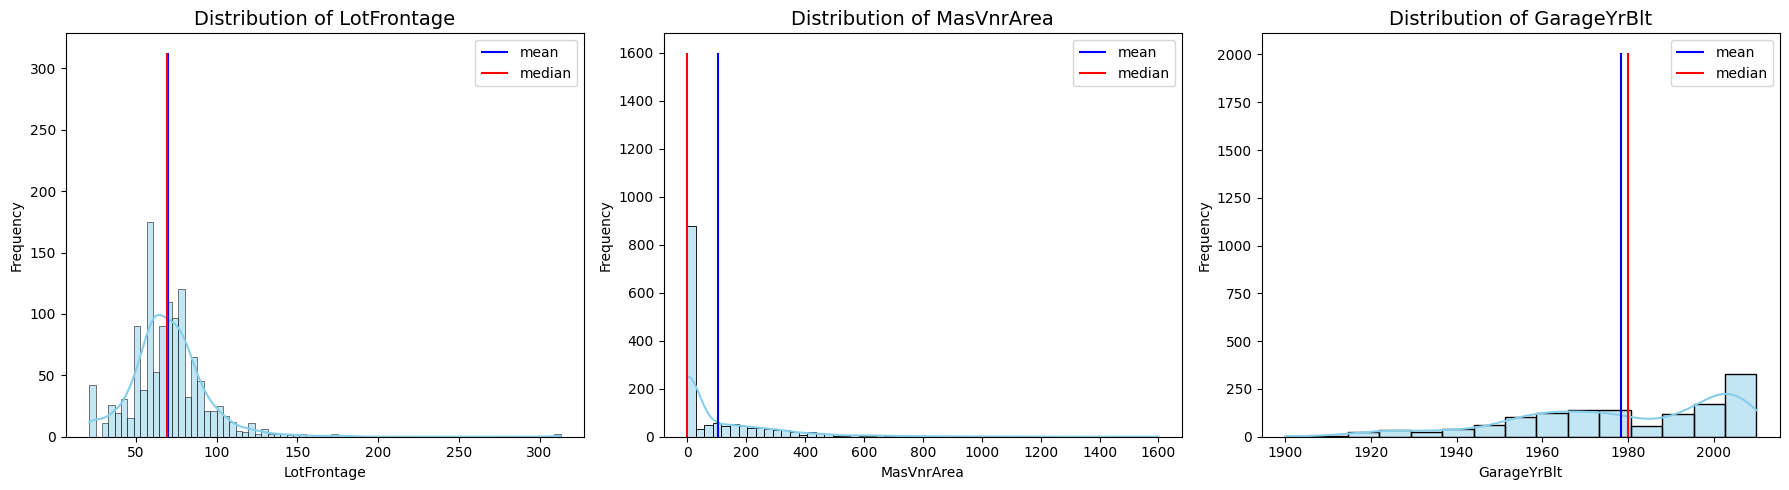

In [49]:
# 결측데이터가 존재하는 실수형 컬럼의 분포 확인
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))
for i, col_name in enumerate(numeric_nan_c):
    sns.histplot(data=df, x=col_name, kde=True, ax=axes[i], color='skyblue')
    axes[i].vlines(df[col_name].mean(), 0, df[col_name].max(), color='b', label='mean')
    axes[i].vlines(df[col_name].median(), 0, df[col_name].max(), color='r', label='median')
    axes[i].set_title(f'Distribution of {col_name}', fontsize=14)
    axes[i].set_xlabel(col_name)
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    plt.tight_layout()
plt.show()

In [53]:
# fillna메소드 활용 결측데이터 채우기
X_train['LotFrontage'] = X_train['LotFrontage'].fillna(X_train['LotFrontage'].mean()) # 파라메터 값으로 결측데이터를 처리(보간) 채워넣는 작업
X_test['LotFrontage'] = X_test['LotFrontage'].fillna(X_train['LotFrontage'].mean())

np.int64(0)

In [55]:
# MasVnrArea 중앙값으로 결측 데이터 처리
X_train['MasVnrArea'] = X_train['MasVnrArea'].fillna(X_train['MasVnrArea'].median())
X_test['MasVnrArea'] = X_test['MasVnrArea'].fillna(X_train['MasVnrArea'].median())

#### **5.1.2 SimpleImputer**
- 데이터셋의 결측데이터를 특정 통계량 혹은 상수로 채워넣는 scikit-learn의 대표적인 전처리 모델  
- strategy 파라메터에 mean(평균), median(중앙값), most_frequent(최빈값), constant(상수)를 전달하여 결측데이터 처리
- train 데이터를 학습(fit)한 통계량을 학습데이터와 테스트 데이터에 동일하게 적용 학습데이터의 데이터 누수를 막는 방법을 사용

In [58]:
# sklearn.impute SimpleImputer 활용 평균값으로 치환
# 전처리 모델을 사용
# ML 모델과는 다르게 목적은 데이터 변환
# 데이터 변환을 하기 위한 기본적인 정보를 FIT으로 학습
# 변환과정은 transform
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')
imputer.fit(X_train[numeric_nan_c])
X_train[numeric_nan_c] = imputer.transform(X_train[numeric_nan_c])
X_test[numeric_nan_c] = imputer.transform(X_test[numeric_nan_c])
imputer.transform(X_train[numeric_nan_c])

array([[  70.,    0., 1957.],
       [  59.,    0., 1993.],
       [  67.,    0., 2005.],
       ...,
       [  60.,    0., 1957.],
       [  55.,    0., 1925.],
       [  53.,  130., 2007.]])

### **5.2 Categorical distribution(범주형 변수 결측데이터 처리)**
- 숫자형과 비슷하게 분포를 확인 후 분포를 해치지 않는 값을 선택하는 것이 좋음
- 범주형 분포에서는 평균/중앙값을 사용하지 못하기에 데이터 분포 상 가장 자주 발생하는 고윳값(최빈값)을 사용하게 된다.
- 일반적으로 범주형 변수의 경우 데이터타입이 문자열타입이기에 이를 먼저 처리해주는 작업이 필요

In [60]:
# 변수 선별
# 결측데이터가 존재 하면서 카테고리컬 한 분포를 보이는 변수
cat_nan_c = [cn for cn in df.columns if (df[cn].dtype == 'object') & (df[cn].isna().any())]

In [62]:
len(cat_nan_c)

16

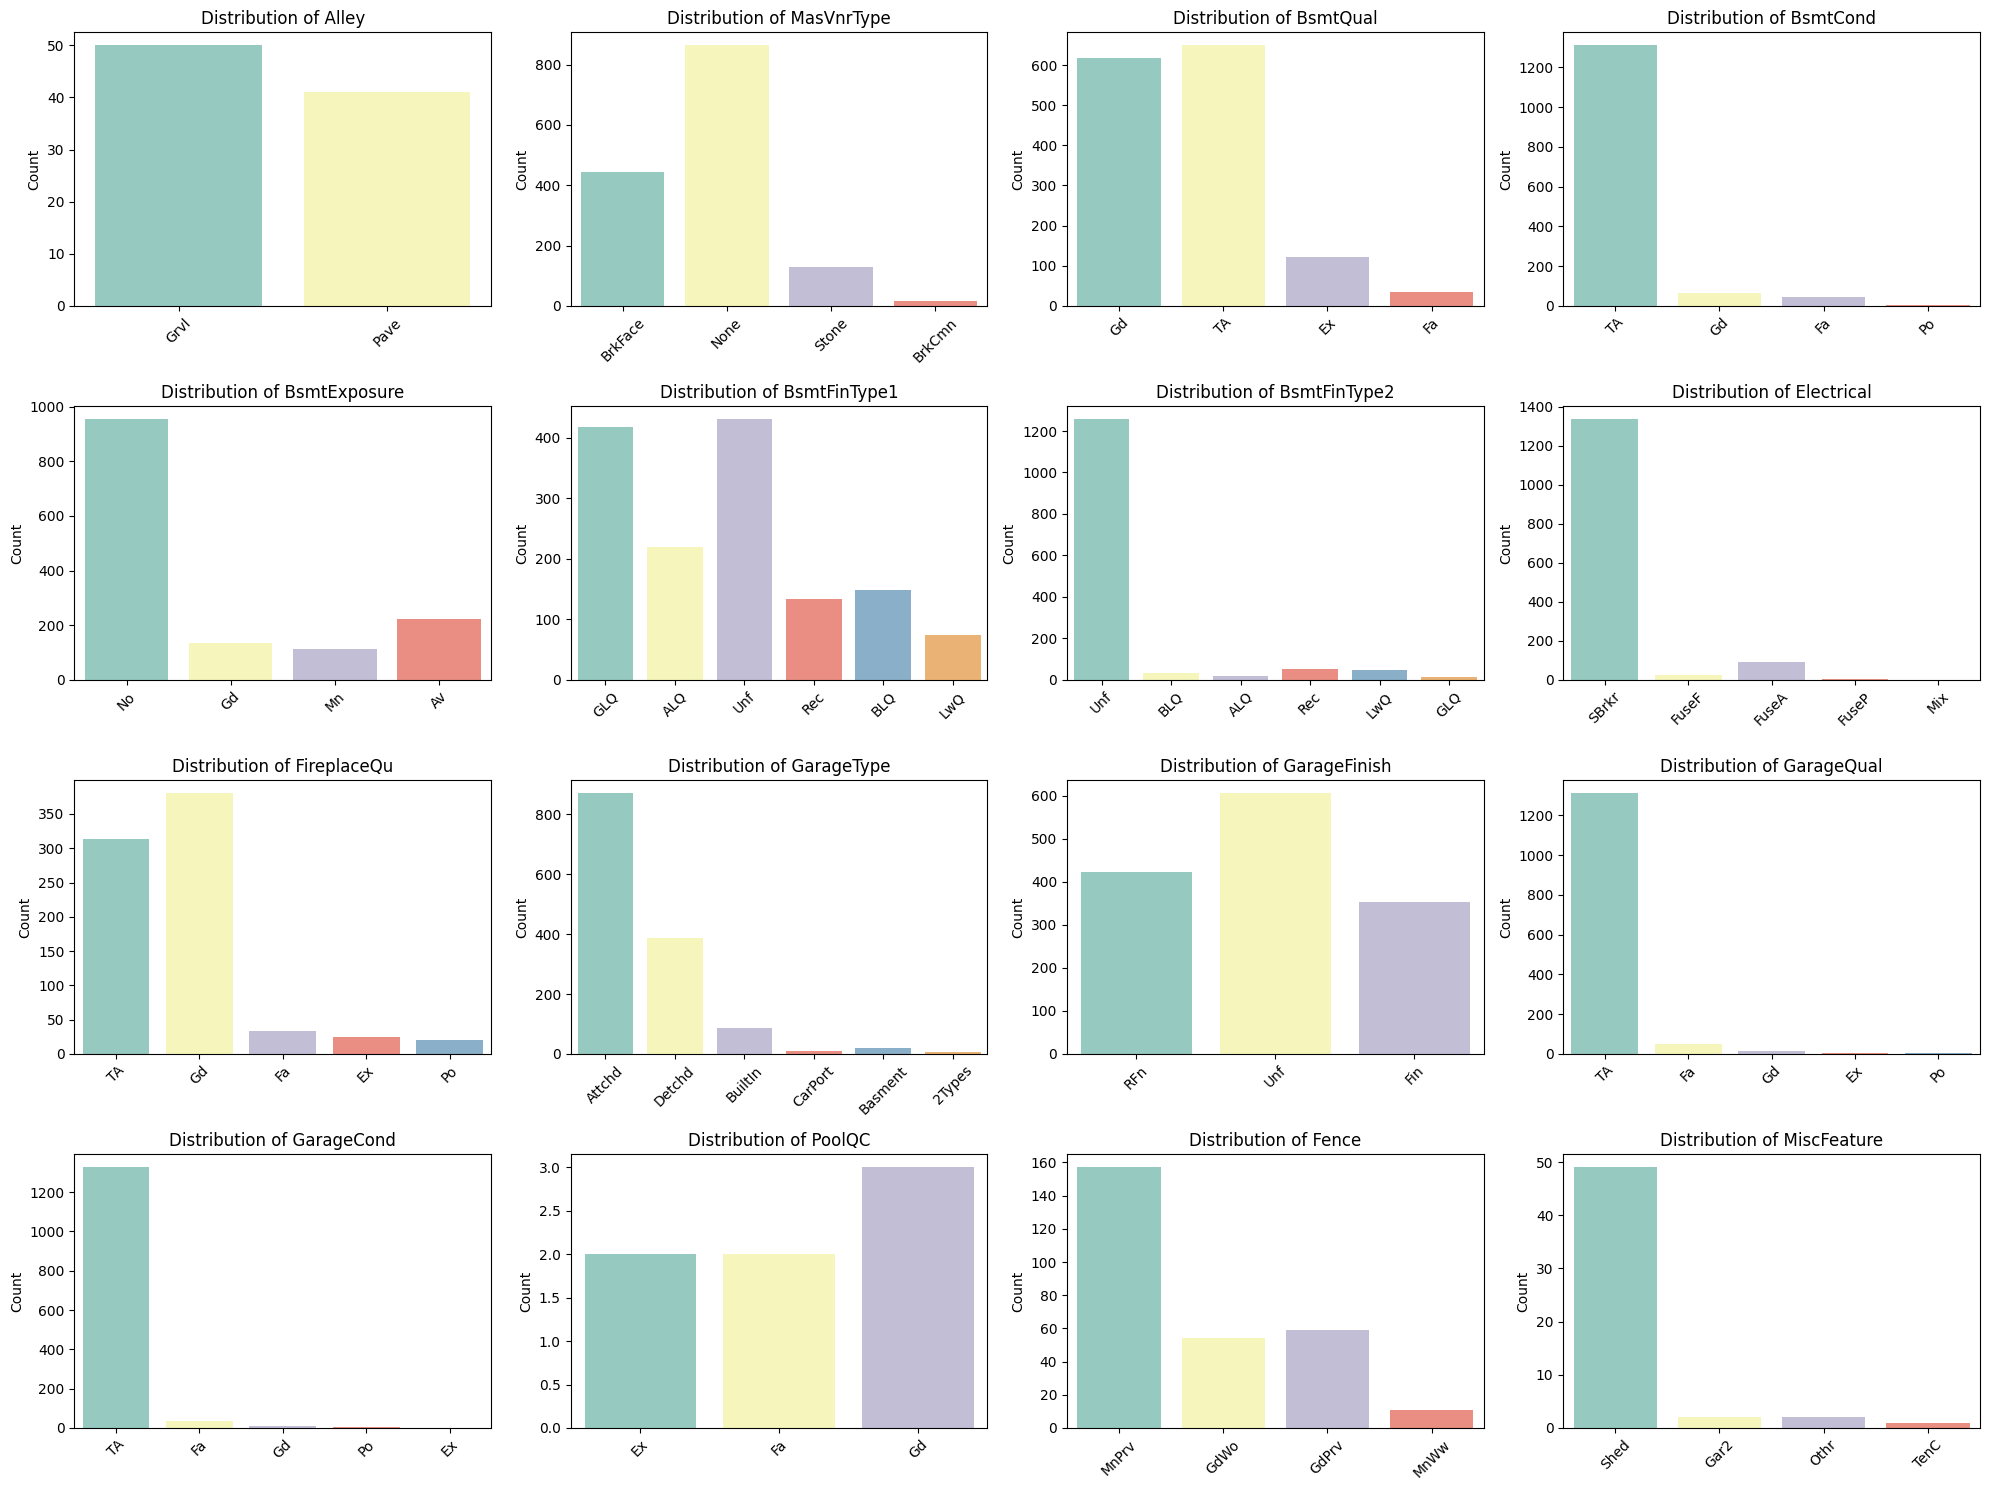

In [63]:
# 결측데이터가 존재하는 범주형 변수의 분포 확인
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 15))
axes_flat = axes.ravel() # 매트릭스 반복을 편하게 벡터형태로 플랫화
for i, col_name in enumerate(cat_nan_c):
    sns.countplot(data=df, x=col_name, ax=axes_flat[i], palette='Set3', legend=False, hue=col_name)
    axes_flat[i].set_title(f'Distribution of {col_name}', fontsize=12)
    axes_flat[i].set_xlabel('')
    axes_flat[i].set_ylabel('Count')
    axes_flat[i].tick_params(axis='x', rotation=45) # x축 표기 텍스트 45도로 돌리기
plt.tight_layout()
plt.show();

Alley 변수의 결측데이터는 없음을 의미,MasVnrType의 결측데이터는 실제 비어있는 데이터  
각 변수의 결측치 특징에 따라 서로 다른 의미가 있을 수 있기에 반드시 데이터 확인 후 도메인 적용 필요

In [66]:
# 범주형 변수 고윳값 확인
X_train['Alley'].unique()
X_train['Alley'].value_counts()

,count
Alley,
Grvl,44
Pave,30


In [67]:
# fillna 적용 (결측 처리가 아닌 하나의 카테고리 화)
X_train['Alley'] = X_train['Alley'].fillna('unable')
X_test['Alley'] = X_test['Alley'].fillna('unable')

In [70]:
# SimpleImputer 적용
cat_imputer = SimpleImputer(strategy='most_frequent')
cat_imputer.fit(X_train[cat_nan_c])
X_train[cat_nan_c] = cat_imputer.transform(X_train[cat_nan_c])
X_test[cat_nan_c] = cat_imputer.transform(X_test[cat_nan_c])

In [72]:
# 처리 후 결측 데이터 확인
X_train.isna().sum()
X_test.isna().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
Street,0
Alley,0
LotShape,0
LandContour,0
Utilities,0


In [73]:
# 현재 과정까지 수행한 데이터 저장
import joblib

data_dict = {
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
}

joblib.dump(data_dict, './data_dict.joblib')

['./data_dict.joblib']

### 베이스라인 모델과 모델 퍼포먼스 비교

In [74]:
# 유니크 딕셔너리 카테고리컬 변환
unique_dict = {}
for c in X_train.columns:
    if X_train[c].dtype == 'object':
        unique_dict[c] = {k: i for i, k in enumerate(X_train[c].unique(), 0)}

# 문자열 변환
for c in unique_dict:
    X_train[c] = X_train[c].map(unique_dict[c])
    X_test[c] = X_test[c].map(unique_dict[c])

model = XGBRegressor(random_state=42)
pred = model.fit(X_train, y_train).predict(X_test)
print(f'RMSE: {root_mean_squared_error(y_test, pred)}')
print(f'R2: {r2_score(y_test, pred)}')

RMSE: 27263.45703125
R2: 0.9030945897102356


In [ ]:
'''
RMSE: 27501.912109375
R2: 0.9013920426368713
'''